# Dynamic ETA Delay Prediction — Exploratory & Model Comparison Notebook

This notebook walks through the full end-to-end Machine Learning Pipeline developed according to `ml_pipeline_design.md`:
1. **Raw Data Inspection & Audit**: Null counts, dataset stats, and distributions.
2. **Preprocessing**: Filtering cancelled journeys, handling nulls, and deduplicating.
3. **Feature Engineering**: Deriving live delay signals, schedule context, route position, and weather risk scores.
4. **Time-Based Train/Test Split**: Jan-Oct 2023 (Train) vs Nov-Dec 2023 (Test).
5. **Model Benchmarking**: Comparing Linear Regression, Decision Tree, Random Forest, Gradient Boosting, HistGradient Boosting, and LightGBM.
6. **Best Model Diagnostics**: Feature importances, predicted vs actual scatter, and residual distributions.
7. **Sample ETA Predictions**: Interactive prediction queries.


In [1]:
import sys
from pathlib import Path
BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.config import RAW_DATA_PATH, PROCESSED_TRAIN_PATH, PROCESSED_TEST_PATH, MODEL_DIR, TARGET_COL, SPLIT_DATE
from src.preprocessing import load_raw_data, preprocess_data
from src.features import FeaturePipeline, FINAL_FEATURE_COLS
from src.predict import predict_delay_and_eta

sns.set_theme(style="whitegrid")
print("Environment initialized successfully.")


Environment initialized successfully.


## 1. Raw Dataset Inspection & Audit

In [2]:
raw_df = load_raw_data(RAW_DATA_PATH)
print(f"Dataset Shape: {raw_df.shape}")
print("\nMissing Value Audit:")
print(raw_df.isnull().sum()[raw_df.isnull().sum() > 0])
raw_df.head(3)


Dataset Shape: (108800, 23)

Missing Value Audit:
lat                   1080
lon                   1080
temperature_c         1080
precipitation_mm      1080
visibility_m        108800
dtype: int64


,train_no,train_name,journey_date,day_of_week,is_holiday,season,station_code,station_name,lat,lon,...,scheduled_departure,historical_avg_delay_min,simulated_delay_min,simulated_cancelled_flag,previous_station_delay,distance_remaining,number_of_stops_remaining,temperature_c,precipitation_mm,visibility_m
0,11013,COIMBATORE E,2023-01-01,Sunday,False,Winter,LTT,LOKMANYA TIL,19.070320,72.891739,...,22:35:00,0.0,6.7,False,0.0,1518.0,34,21.8,0.0,NaN
1,11013,COIMBATORE E,2023-01-01,Sunday,False,Winter,TNA,THANE,19.185757,72.975417,...,22:55:00,26.0,16.6,False,6.7,1501.0,33,21.7,0.0,NaN
2,11013,COIMBATORE E,2023-01-01,Sunday,False,Winter,KYN,KALYAN JN,19.234716,73.129740,...,23:18:00,30.0,11.2,False,16.6,1481.0,32,22.2,0.0,NaN


## 2. Delay Distribution Analysis

C:\Users\sumit\AppData\Local\Temp\ipykernel_11956\319810611.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw_df, x="season", y=TARGET_COL, palette="Set2")


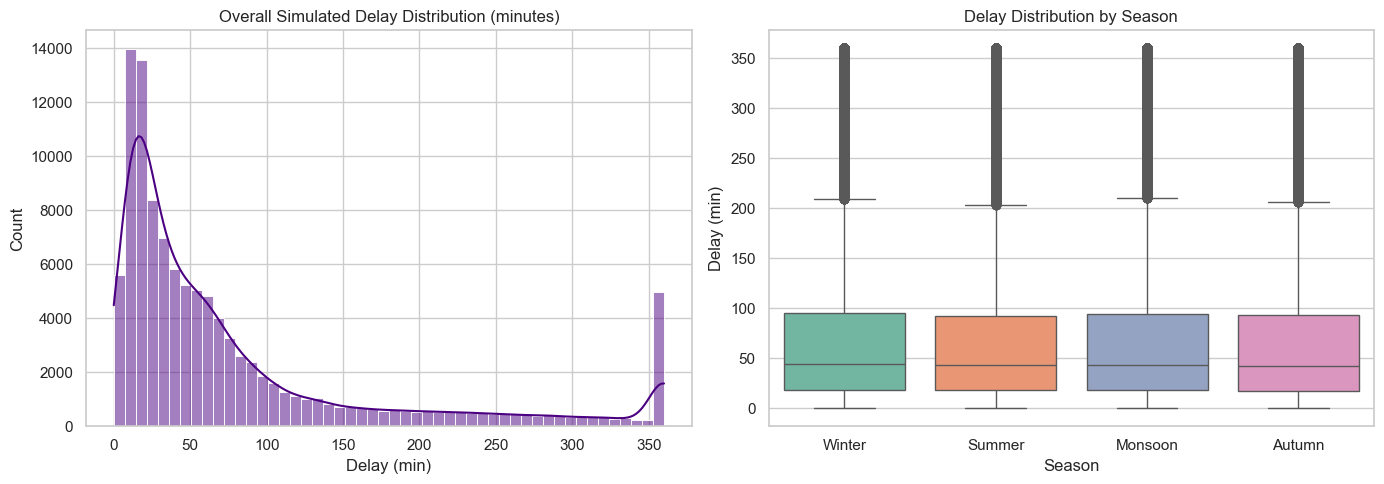

In [3]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(raw_df[TARGET_COL], bins=50, kde=True, color="indigo")
plt.title("Overall Simulated Delay Distribution (minutes)")
plt.xlabel("Delay (min)")

plt.subplot(1, 2, 2)
sns.boxplot(data=raw_df, x="season", y=TARGET_COL, palette="Set2")
plt.title("Delay Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Delay (min)")

plt.tight_layout()
plt.show()


## 3. Preprocessing & Feature Engineering Walkthrough

In [4]:
clean_df = preprocess_data(raw_df, filter_cancelled=True)
pipeline = FeaturePipeline()
feat_df = pipeline.fit_transform(clean_df, TARGET_COL)

print(f"Clean non-cancelled dataset shape: {clean_df.shape}")
print(f"Engineered feature set shape: {feat_df[FINAL_FEATURE_COLS].shape}")

feat_df[['previous_station_delay', 'delay_trend', 'rolling_avg_delay_last_3', 'pct_journey_complete', 'weather_risk_score']].head()


[PREPROCESSING] Cancelled rows filter: 108800 -> 106892 (removed 1908)
Clean non-cancelled dataset shape: (105182, 23)
Engineered feature set shape: (105182, 27)


,previous_station_delay,delay_trend,rolling_avg_delay_last_3,pct_journey_complete,weather_risk_score
0,0.0,0.0,0.000000,0.000000,0.0
1,6.7,-19.3,3.350000,0.011199,0.0
2,16.6,-13.4,7.766667,0.024374,0.0
3,11.2,11.2,11.500000,0.115283,0.0
4,46.2,-13.8,24.666667,0.238472,0.0


## 4. Time-Based Train/Test Split Visualization

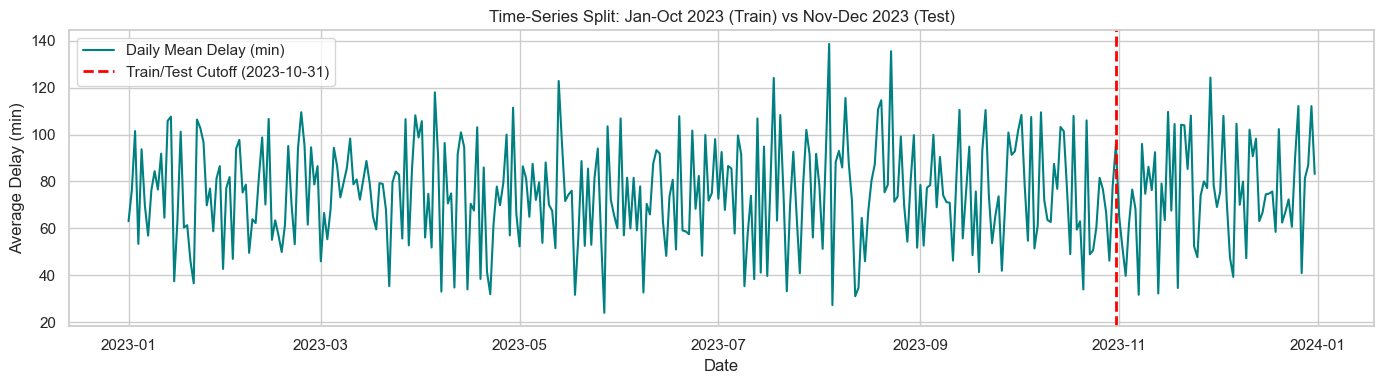

In [5]:
feat_df['journey_date'] = pd.to_datetime(feat_df['journey_date'])
daily_avg = feat_df.groupby('journey_date')[TARGET_COL].mean().reset_index()

plt.figure(figsize=(14, 4))
plt.plot(daily_avg['journey_date'], daily_avg[TARGET_COL], label="Daily Mean Delay (min)", color="teal")
plt.axvline(pd.to_datetime(SPLIT_DATE), color="red", linestyle="--", linewidth=2, label=f"Train/Test Cutoff ({SPLIT_DATE})")
plt.title("Time-Series Split: Jan-Oct 2023 (Train) vs Nov-Dec 2023 (Test)")
plt.xlabel("Date")
plt.ylabel("Average Delay (min)")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Model Benchmark & Comparison

BENCHMARK COMPARISON TABLE (Non-Capped Test Set Evaluation):


,MAE,RMSE,R2,Within_5min_%,Within_10min_%
Linear Regression,31.7933,60.1088,0.2558,19.47,36.46
Decision Tree,27.6654,46.2126,0.5601,23.30,41.34
Random Forest,25.1691,40.0044,0.6704,23.01,41.29
Gradient Boosting,25.0601,39.5634,0.6776,23.05,41.29
HistGradient Boosting,25.0078,39.8237,0.6734,23.25,42.02
LightGBM,24.8999,39.4523,0.6794,22.87,41.69


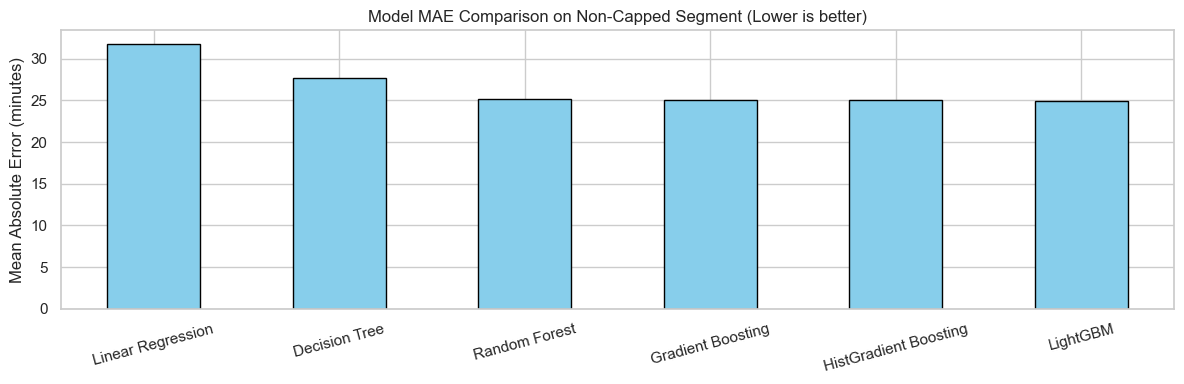

In [6]:
model_bundle = joblib.load(MODEL_DIR / "best_model.joblib")
all_results = model_bundle.get("all_results_v2", {}).get("non_capped", model_bundle.get("all_results", {}))
results_df = pd.DataFrame(all_results).T

print("=" * 65)
print("BENCHMARK COMPARISON TABLE (Non-Capped Test Set Evaluation):")
print("=" * 65)
display(results_df)

plt.figure(figsize=(12, 4))
results_df['MAE'].plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Model MAE Comparison on Non-Capped Segment (Lower is better)")
plt.ylabel("Mean Absolute Error (minutes)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 6. Best Model Diagnostics

Loaded Best Model: LightGBM


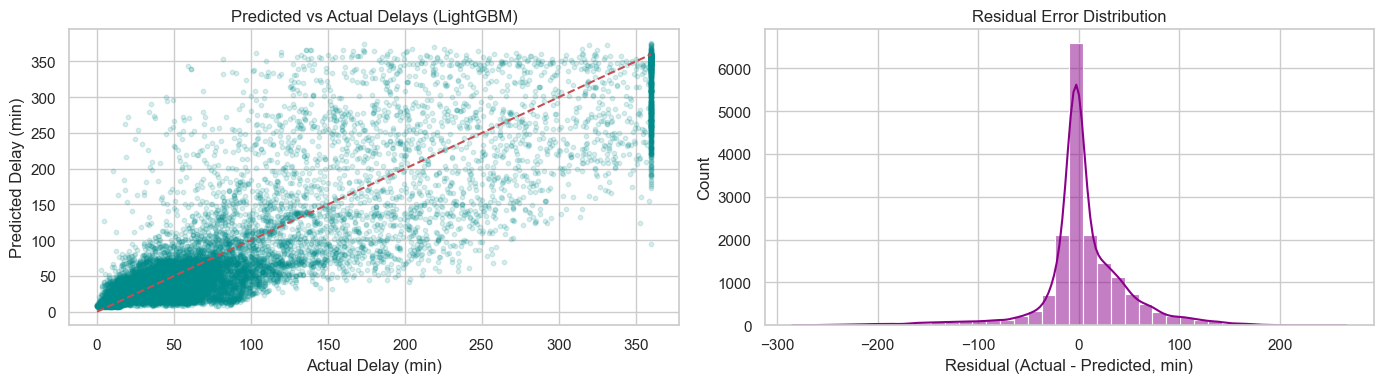

In [7]:
best_model_name = model_bundle["model_name"]
best_model = model_bundle["model"]
target_transform = model_bundle.get("target_transform", "log1p")
print(f"Loaded Best Model: {best_model_name}")

test_df = pd.read_csv(PROCESSED_TEST_PATH)
feature_cols = model_bundle["feature_cols"]
base_cols = model_bundle.get("base_feature_cols", FINAL_FEATURE_COLS)
if 'severe_delay_risk' not in test_df.columns and model_bundle.get("severe_classifier") is not None:
    test_df['severe_delay_risk'] = model_bundle["severe_classifier"].predict_proba(test_df[base_cols])[:, 1]

X_test = test_df[feature_cols]
y_test = test_df[TARGET_COL].values

raw_pred = best_model.predict(X_test)
if target_transform == "log1p":
    y_pred = np.maximum(0, np.expm1(raw_pred))
else:
    y_pred = np.maximum(0, raw_pred)

plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.15, color="darkcyan", s=10)
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--')
plt.title(f"Predicted vs Actual Delays ({best_model_name})")
plt.xlabel("Actual Delay (min)")
plt.ylabel("Predicted Delay (min)")

plt.subplot(1, 2, 2)
sns.histplot(y_test - y_pred, bins=40, kde=True, color="darkmagenta")
plt.title("Residual Error Distribution")
plt.xlabel("Residual (Actual - Predicted, min)")
plt.tight_layout()
plt.show()


## 7. Sample Predictions & ETA Calculation

In [8]:
sample_row = clean_df.iloc[100]
train_no = int(sample_row['train_no'])
journey_date = str(sample_row['journey_date'])[:10]
station_code = str(sample_row['station_code'])

pred_res = predict_delay_and_eta(train_no, journey_date, station_code, raw_df=raw_df)

print("Sample Single-Stop Dynamic ETA Prediction:")
print("-" * 45)
for k, v in pred_res.items():
    print(f"  {k:20s}: {v}")


Sample Single-Stop Dynamic ETA Prediction:
---------------------------------------------
  train_no            : 11013
  journey_date        : 2023-01-16
  station_code        : TUP
  scheduled_arrival   : 05:28:00
  predicted_delay_min : 39.82
  predicted_delay_range_min: [19.2, 87.73]
  interval_width_type : p08_p92 (84% nominal)
  predicted_eta       : 06:07:49
  predicted_eta_range : ['05:47:12', '06:55:43']
  confidence          : Medium
  severe_delay_risk   : 0.0
  chronic_tier_is_fallback: 0
  event_type          : NONE
  event_elapsed_min   : 0.0
  event_expected_min  : 0.0
  is_cancelled        : False
  status              : DELAYED
